# 图片文件夹数据增强与 DataLoader

这个 notebook 演示 PyTorch 数据加载的标准工业流程：直接读取已经按类别导出的图片文件夹，用 `random_split` 按固定 9:1 比例划分训练集和验证集，再交给 `DataLoader` 管批次。这里补上了 `collate_fn`，把“样本列表 -> 批次张量”的组装过程显式写出来。命令行入口使用 `click`，日志与调试输出统一使用 `logging`，并落盘到日志文件中。

## 1. 总体流程

1. 直接读取已经按类别整理好的图片文件夹。
2. 用 `ImageFolder` 读取图片与标签。
3. 给训练集加数据增强，验证集只做标准化。
4. 用 `collate_fn` 显式组装 batch，再交给 `DataLoader`。
5. 用 `click` 暴露命令行参数，用 `logging` 记录信息。

In [7]:
from __future__ import annotations

import logging
import random
from pathlib import Path

import click
import torch
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid

DEFAULT_ROOT_DIR = Path(r"d:\Jupyter Lab\CiFar10\cifar-10-batches-py\export")
DEFAULT_LOG_DIR = Path(r"d:\Jupyter Lab\CiFar10\Log")
DEFAULT_LOG_NAME = "image_folder_dataloader.log"
DEFAULT_SEED = 42
DEFAULT_BATCH_SIZE = 32
DEFAULT_IMAGE_SIZE = 32
DEFAULT_NUM_WORKERS = 0
DEFAULT_MEAN = (0.4914, 0.4822, 0.4465)
DEFAULT_STD = (0.2470, 0.2435, 0.2616)
DEFAULT_TRAIN_RATIO = 0.9


def setup_logging(log_dir: Path = DEFAULT_LOG_DIR, log_name: str = DEFAULT_LOG_NAME) -> logging.Logger:
    log_dir.mkdir(parents=True, exist_ok=True)
    logger = logging.getLogger("image_folder_dataloader")
    logger.setLevel(logging.INFO)
    logger.propagate = False

    for handler in list(logger.handlers):
        logger.removeHandler(handler)
        handler.close()

    formatter = logging.Formatter("%(asctime)s %(levelname)s %(message)s")
    file_handler = logging.FileHandler(log_dir / log_name, encoding="utf-8")
    file_handler.setFormatter(formatter)
    logger.addHandler(file_handler)

    stream_handler = logging.StreamHandler()
    stream_handler.setFormatter(formatter)
    logger.addHandler(stream_handler)

    return logger





class SplitDataset(Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = list(indices)
        self.transform = transform
        self.classes = getattr(dataset, "classes", [])
        self.class_to_idx = getattr(dataset, "class_to_idx", {})

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, index: int):
        image, label = self.dataset[self.indices[index]]
        if self.transform is not None:
            image = self.transform(image)
        return image, label


def build_datasets(
    root_dir: Path = DEFAULT_ROOT_DIR,
    image_size: int = DEFAULT_IMAGE_SIZE,
    seed: int = DEFAULT_SEED,
) -> tuple[SplitDataset, SplitDataset, list[str]]:
    root_dir = root_dir.resolve()
    base_dataset = datasets.ImageFolder(root_dir)
    total_count = len(base_dataset)
    train_count = int(total_count * DEFAULT_TRAIN_RATIO)
    val_count = total_count - train_count

    generator = torch.Generator().manual_seed(seed)
    train_subset, val_subset = random_split(base_dataset, [train_count, val_count], generator=generator)
    train_transform, eval_transform = build_transforms(image_size=image_size)

    train_dataset = SplitDataset(base_dataset, train_subset.indices, transform=train_transform)
    val_dataset = SplitDataset(base_dataset, val_subset.indices, transform=eval_transform)
    class_names = list(base_dataset.classes)

    return train_dataset, val_dataset, class_names


def build_dataloaders(
    root_dir: Path = DEFAULT_ROOT_DIR,
    batch_size: int = DEFAULT_BATCH_SIZE,
    image_size: int = DEFAULT_IMAGE_SIZE,
    num_workers: int = DEFAULT_NUM_WORKERS,
    seed: int = DEFAULT_SEED,
    logger: logging.Logger | None = None,
    collate_fn=None,
):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    logger = logger or logging.getLogger("image_folder_dataloader")
    collate_fn = collate_fn or build_collate_fn(logger=logger)
    train_dataset, val_dataset, class_names = build_datasets(
        root_dir=root_dir,
        image_size=image_size,
        seed=seed,
    )

    generator = torch.Generator().manual_seed(seed)
    pin_memory = torch.cuda.is_available()
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin_memory, generator=generator, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory, collate_fn=collate_fn)

    logger.info("已加载图片文件夹数据集: root_dir=%s", root_dir)
    logger.info("数据集划分完成: train=%s val=%s", len(train_dataset), len(val_dataset))
    logger.info("类别数量: %s", len(class_names))

    return train_loader, val_loader, class_names


def denormalize(batch: torch.Tensor, mean=DEFAULT_MEAN, std=DEFAULT_STD) -> torch.Tensor:
    mean_tensor = torch.tensor(mean, device=batch.device).view(1, -1, 1, 1)
    std_tensor = torch.tensor(std, device=batch.device).view(1, -1, 1, 1)
    return batch * std_tensor + mean_tensor


def show_batch(images: torch.Tensor, labels: torch.Tensor, class_names: list[str], logger: logging.Logger | None = None, max_images: int = 16) -> None:
    logger = logger or logging.getLogger("image_folder_dataloader")
    count = min(max_images, images.size(0))
    label_ids = labels[:count].tolist()
    label_names = [class_names[label_id] for label_id in label_ids]
    logger.info("批次张量形状: %s", tuple(images.shape))
    logger.info("批次标签: %s", label_ids)
    logger.info("批次类别: %s", label_names)

    grid = make_grid(denormalize(images[:count].cpu()), nrow=4, padding=2)
    plt.figure(figsize=(10, 10))
    plt.axis("off")
    plt.title("Augmented training batch")
    plt.imshow(grid.permute(1, 2, 0).clamp(0, 1))
    plt.show()

## 2. 数据增强与 collate_fn

训练集使用随机裁剪、翻转、旋转和颜色扰动；验证集只做归一化。`collate_fn` 负责把样本列表显式堆叠成 batch 张量。

In [8]:
def build_transforms(image_size: int = DEFAULT_IMAGE_SIZE) -> tuple[transforms.Compose, transforms.Compose]:
    train_transform = transforms.Compose([
        transforms.RandomCrop(image_size, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize(DEFAULT_MEAN, DEFAULT_STD),
    ])

    eval_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(DEFAULT_MEAN, DEFAULT_STD),
    ])

    return train_transform, eval_transform


def build_collate_fn(logger: logging.Logger | None = None):
    logger = logger or logging.getLogger("image_folder_dataloader")

    def collate_fn(batch):
        images, labels = zip(*batch)
        batch_images = torch.stack(list(images), dim=0)
        batch_labels = torch.tensor(labels, dtype=torch.long)
        logger.debug("collate_fn 组装 batch: size=%s shape=%s", len(batch), tuple(batch_images.shape))
        return batch_images, batch_labels

    return collate_fn

def preview_training_batch(
    root_dir: Path = DEFAULT_ROOT_DIR,
    batch_size: int = DEFAULT_BATCH_SIZE,
    image_size: int = DEFAULT_IMAGE_SIZE,
    num_workers: int = DEFAULT_NUM_WORKERS,
    seed: int = DEFAULT_SEED,
    logger: logging.Logger | None = None,
):
    logger = logger or logging.getLogger("image_folder_dataloader")
    train_loader, val_loader, class_names = build_dataloaders(
        root_dir=root_dir,
        batch_size=batch_size,
        image_size=image_size,
        num_workers=num_workers,
        seed=seed,
        logger=logger,
    )
    images, labels = next(iter(train_loader))
    logger.info("已加载一个训练批次用于预览")
    return images, labels, class_names, train_loader, val_loader

## 3. Click 命令行入口

使用 `click` 接收图片根目录、batch size、image size、worker 数和随机种子等参数，便于在终端直接跑完整的数据加载流程。

In [9]:
@click.command()
@click.option("--root-dir", type=click.Path(path_type=Path, exists=True, file_okay=False, dir_okay=True), default=DEFAULT_ROOT_DIR, show_default=True, help="图片根目录，目录下按类别存放图片。")
@click.option("--batch-size", type=int, default=DEFAULT_BATCH_SIZE, show_default=True, help="批次大小。")
@click.option("--image-size", type=int, default=DEFAULT_IMAGE_SIZE, show_default=True, help="训练时使用的图像尺寸。")
@click.option("--num-workers", type=int, default=DEFAULT_NUM_WORKERS, show_default=True, help="DataLoader worker 数量。")
@click.option("--seed", type=int, default=DEFAULT_SEED, show_default=True, help="随机种子。")
@click.option("--log-dir", type=click.Path(path_type=Path, file_okay=False, dir_okay=True), default=DEFAULT_LOG_DIR, show_default=True, help="日志文件保存目录。")
@click.option("--log-name", type=str, default=DEFAULT_LOG_NAME, show_default=True, help="日志文件名。")
def main(root_dir: Path, batch_size: int, image_size: int, num_workers: int, seed: int, log_dir: Path, log_name: str) -> None:
    logger = setup_logging(log_dir=log_dir, log_name=log_name)
    train_loader, val_loader, class_names = build_dataloaders(
        root_dir=root_dir,
        batch_size=batch_size,
        image_size=image_size,
        num_workers=num_workers,
        seed=seed,
        logger=logger,
    )
    logger.info("训练集 batch 数: %s", len(train_loader))
    logger.info("验证集 batch 数: %s", len(val_loader))
    logger.info("类别名称: %s", class_names)

## 4. Notebook 内验证

在 notebook 里直接构造 DataLoader、取一个训练批次并可视化增强效果，同时把运行结果写入日志文件。

2026-05-22 15:38:20,174 INFO 已加载图片文件夹数据集: root_dir=d:\Jupyter Lab\CiFar10\cifar-10-batches-py\export
2026-05-22 15:38:20,174 INFO 数据集划分完成: train=45000 val=5000
2026-05-22 15:38:20,174 INFO 类别数量: 10
2026-05-22 15:38:20,200 INFO 已加载一个训练批次用于预览
2026-05-22 15:38:20,202 INFO 训练集 batch 数: 1407
2026-05-22 15:38:20,202 INFO 验证集 batch 数: 157
2026-05-22 15:38:20,204 INFO 批次张量形状: (32, 3, 32, 32)
2026-05-22 15:38:20,205 INFO 批次标签: [0, 7, 8, 6, 0, 1, 5, 1, 1, 6, 0, 7, 1, 1, 7, 6]
2026-05-22 15:38:20,205 INFO 批次类别: ['airplane', 'horse', 'ship', 'frog', 'airplane', 'automobile', 'dog', 'automobile', 'automobile', 'frog', 'airplane', 'horse', 'automobile', 'automobile', 'horse', 'frog']


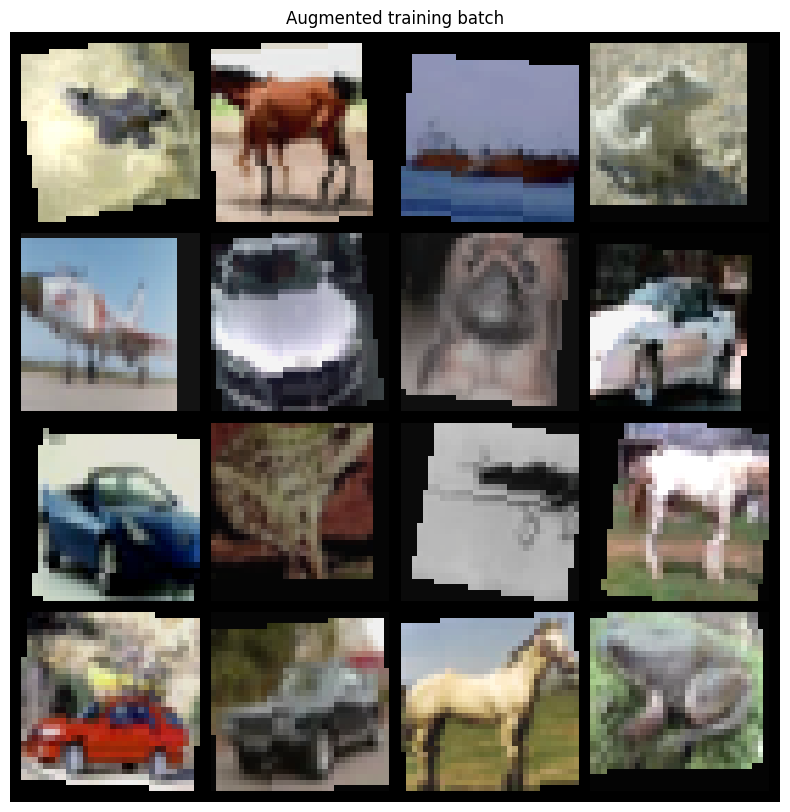

2026-05-22 15:38:20,274 INFO 日志文件: d:\Jupyter Lab\CiFar10\Log\image_folder_dataloader.log
2026-05-22 15:38:20,274 INFO 日志文件是否存在: True


In [10]:
root_dir = DEFAULT_ROOT_DIR
logger = setup_logging()
images, labels, class_names, train_loader, val_loader = preview_training_batch(
    root_dir=root_dir,
    batch_size=DEFAULT_BATCH_SIZE,
    image_size=DEFAULT_IMAGE_SIZE,
    num_workers=DEFAULT_NUM_WORKERS,
    seed=DEFAULT_SEED,
    logger=logger,
)
logger.info("训练集 batch 数: %s", len(train_loader))
logger.info("验证集 batch 数: %s", len(val_loader))
show_batch(images, labels, class_names, logger=logger)
log_file = DEFAULT_LOG_DIR / DEFAULT_LOG_NAME
logger.info("日志文件: %s", log_file)
logger.info("日志文件是否存在: %s", log_file.exists())